# Autoregressive Character-level Language Model

In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
names = []
with open('italian_names_dataset/italian_popular_masculine_names.txt') as f:
    names.extend(f.read().lower().splitlines())
with open('italian_names_dataset/italian_popular_feminine_names.txt') as f:
    names.extend(f.read().lower().splitlines())

## Markov Chain Approach

Markov Chain is treated as a bigram probability matrix.

In [3]:
bigrams = {}
for name in names:
    w = ['<START>'] + list(name) + ['<END>']
    for a, b in zip(w, w[1:]):
        bigrams[(a, b)] = bigrams.get((a, b), 0) + 1


In [4]:
sorted(bigrams.items(), key=lambda x: x[1], reverse=True)[:10]

[(('o', '<END>'), 334),
 (('a', '<END>'), 231),
 (('a', 'n'), 138),
 (('i', 'a'), 102),
 (('i', 'o'), 96),
 (('<START>', 'a'), 92),
 (('a', 'r'), 89),
 (('r', 'i'), 85),
 (('e', 'l'), 83),
 (('n', 'a'), 83)]

In [4]:
chars = sorted(list(set(''.join(names))))
stoi = {s: i+1 for i, s in enumerate(chars)} # string to int
stoi['.'] = 0
stoi = {k: v for k, v in sorted(stoi.items(), key=lambda x: x[1])}
itos = {i: s for s, i in stoi.items()} # int to string

In [5]:
N = torch.zeros((len(stoi), len(stoi)), dtype=torch.int32)

for name in names:
    w = ['.'] + list(name) + ['.']
    for a, b in zip(w, w[1:]):
        N[stoi[a], stoi[b]] += 1

(np.float64(-0.5), np.float64(28.5), np.float64(28.5), np.float64(-0.5))

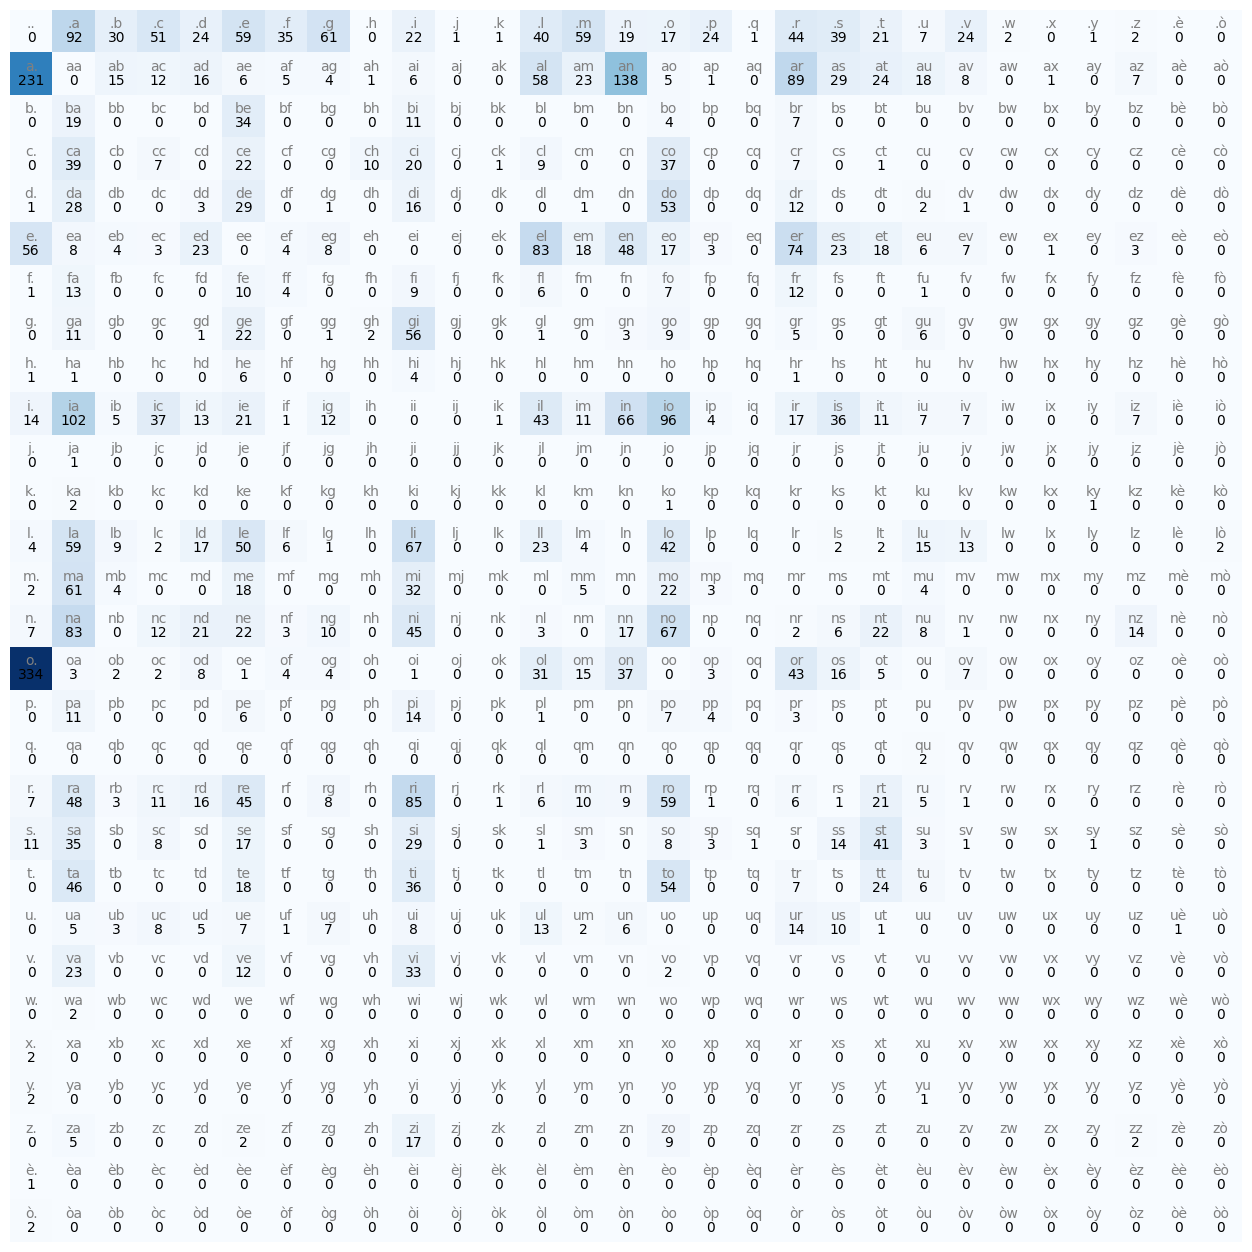

In [64]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(len(stoi)):
    for j in range(len(stoi)):
        plt.text(j, i, itos[i] + itos[j], ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='black')
plt.axis('off')

In [6]:
P = N.to(torch.float32)
P /= P.sum(1, keepdim=True)

# N = N.to(torch.float32)
# for i in range(len(N)):
#    N[i] = N[i] / N[i].sum()

In [9]:
P.sum(1, keepdim=True)

tensor([[1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000]])

(np.float64(-0.5), np.float64(28.5), np.float64(28.5), np.float64(-0.5))

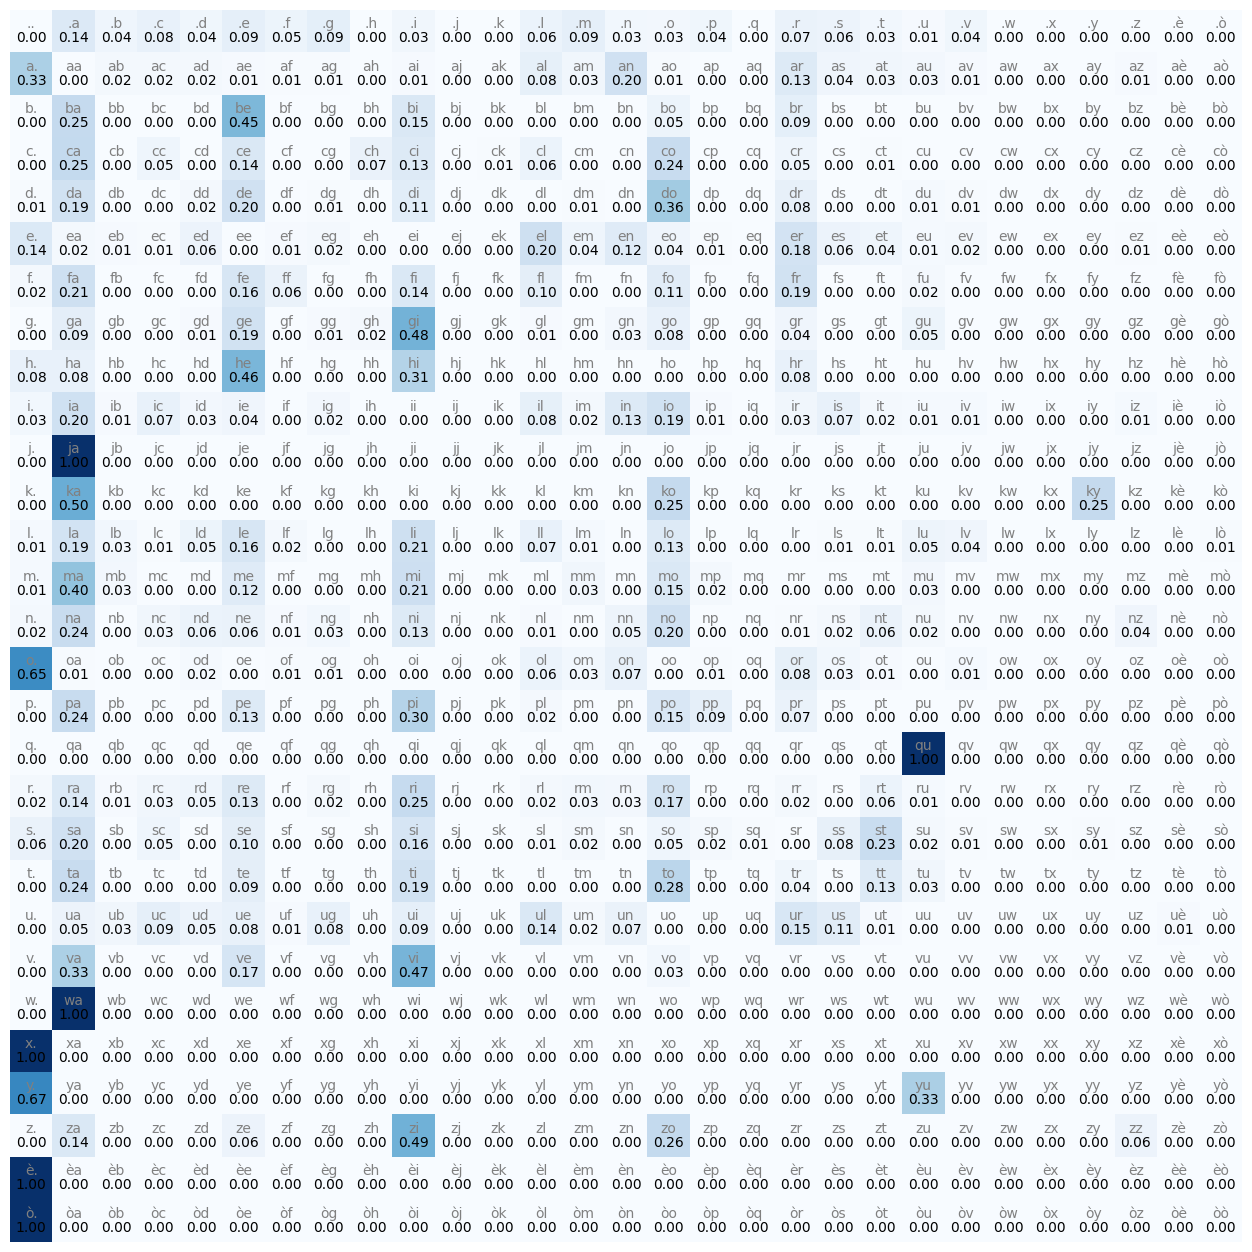

In [10]:
plt.figure(figsize=(16, 16))
plt.imshow(P, cmap='Blues')
for i in range(len(stoi)):
    for j in range(len(stoi)):
        plt.text(j, i, itos[i] + itos[j], ha='center', va='bottom', color='gray')
        plt.text(j, i, f'{P[i, j]:.2f}', ha='center', va='top', color='black') 
plt.axis('off')

In [7]:
gen_names = set()

for _ in range(1000):
    letter = '.'
    name = ''
    while True:
        ix = stoi[letter]
        probs = P[ix]
        letter = itos[torch.multinomial(probs, num_samples=1, replacement=True).item()]
        if letter == '.':
            break
        name += letter
    gen_names.add(name)

In [30]:
counter = 0

for name in sorted(gen_names):
    if name in names:
        print(name)
        counter += 1

print(f'{counter} out of {len(gen_names)} were real ({counter/len(gen_names)*100:.2f}%)')

aris
edo
ema
eva
leo
milo
mina
odo
piero
pino
rico
sara
12 out of 775 were real (1.55%)


### Quality of network

In [31]:
P_smoothed = (N + 1).to(torch.float32) # add-one smoothing (avoid infinity in nll)
P_smoothed /= P_smoothed.sum(1, keepdim=True)

for name in names[:10]:
    size = len(name) + 1
    w = ['.'] + list(name) + ['.']
    log_likelihood = 0.0
    for a, b in zip(w, w[1:]):
        log_likelihood += torch.log(P_smoothed[stoi[a], stoi[b]])
    log_likelihood /= size
    # We want to maximize the likelihood -> minimize the negative log-likelihood (nll)
    nll = - log_likelihood
    print(f'{name}: {nll.item():.4f}')

christian: 2.3120
walter: 3.3006
samuel: 2.8852
manuel: 2.4999
max: 2.9399
victor: 2.7593
luigi: 2.7937
carlo: 2.1263
andrea: 2.3176
mario: 1.5476


## Single Neural Layer Approach

In [8]:
xs, ys = [], []

for name in names:
    w = ['.'] + list(name) + ['.']
    for a, b in zip(w, w[1:]):
        xs.append(stoi[a])
        ys.append(stoi[b])

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [9]:
import torch.nn.functional as F

x_encoded = F.one_hot(xs, num_classes=len(stoi)).float()

In [10]:
W = torch.randn((len(stoi), len(stoi)), requires_grad=True)

Softmax with temperature $T = 1$ $$\sigma(z_j) = \frac{e^{z_j}}{\sum_{k=1}^{n} e^{z_k}}$$

Softmax with temperature $T$ generic $$\sigma(z_j) = \frac{e^{z_j/T}}{\sum_{k=1}^{n} e^{z_k/T}}$$

$T = 0 \Rightarrow$ *argmax* (deterministic) \
$T \rightarrow +\infty \Rightarrow$ *random* (equally probability)

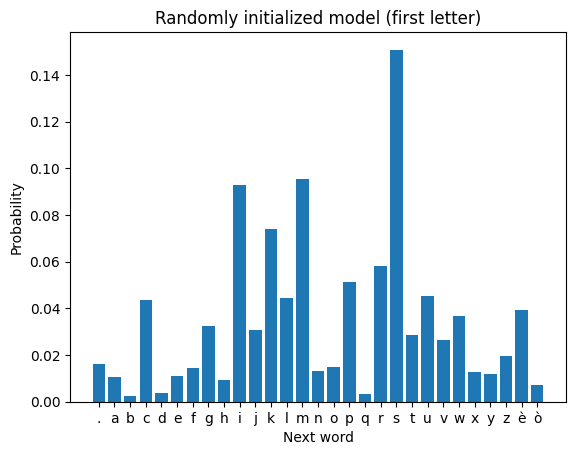

In [79]:
logits = x_encoded @ W
probs = F.softmax(logits, dim=1)

# SOFTMAX MANUAL IMPLEMENTATION
# prob = logits.exp()
# probs = prob / prob.sum(1, keepdim=True)

plt.bar(stoi.keys(), probs[0].detach().numpy())
plt.xlabel("Next word")
plt.ylabel("Probability")
plt.title("Randomly initialized model (first letter)")
plt.show()

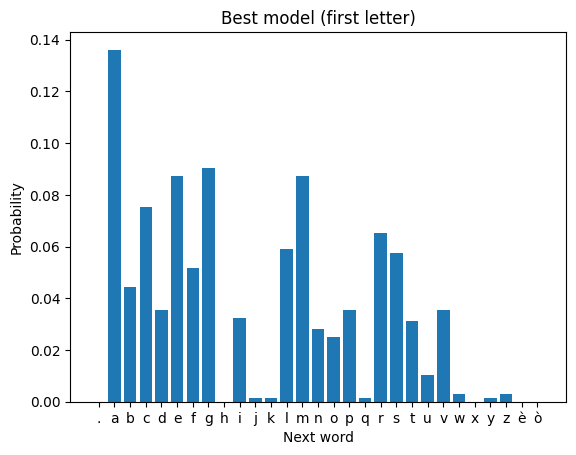

In [80]:
plt.bar(stoi.keys(), P[stoi['.']].detach().numpy())
plt.xlabel("Next word")
plt.ylabel("Probability")
plt.title("Best model (first letter)")
plt.show()

NLL is our loss function. W is the matrix of weights in out model. Completely random.
The loss will tend **not** to 0 but to the real minimum given by the average nll of the best model shown above.
We **cannot** achieve better results.

In [15]:
P = N.to(torch.float32)
P /= P.sum(1, keepdim=True)

log_likelihood = 0.0
n = 0

for name in names:
    size = len(name) + 1
    w = ['.'] + list(name) + ['.']
    for a, b in zip(w, w[1:]):
        log_likelihood += torch.log(P[stoi[a], stoi[b]])
    n += size

log_likelihood /= n
nll = - log_likelihood
print(f'Average negative log-likelihood: {nll.item():.4f}')

Average negative log-likelihood: 2.1426


00000 3.6276016235351562
00500 2.3189122676849365
01000 2.237025022506714
01500 2.2077441215515137
02000 2.192629098892212
02500 2.1833438873291016
03000 2.1770410537719727
03500 2.17246150970459
04000 2.1689658164978027
04500 2.1661975383758545
05000 2.1639442443847656
05500 2.1620709896087646
06000 2.1604862213134766
06500 2.159127950668335
07000 2.1579501628875732
07500 2.156918525695801
08000 2.1560072898864746
08500 2.1551969051361084
09000 2.1544711589813232
09500 2.1538171768188477
10000 2.1532251834869385


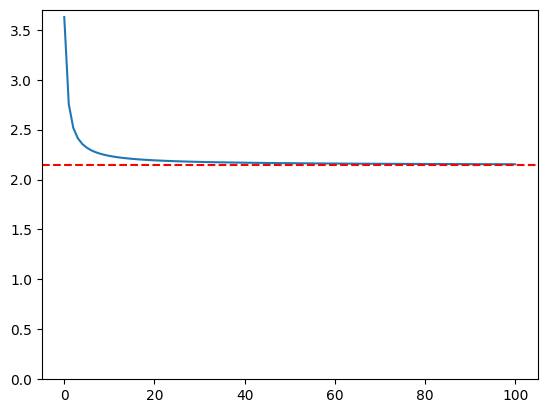

In [33]:
W = torch.randn((len(stoi), len(stoi)), requires_grad=True)

hist = []

for k in range(10_000 + 1):
    x_encoded = F.one_hot(xs, num_classes=len(stoi)).float()
    logits = x_encoded @ W
    probs = F.softmax(logits, dim=1)
    loss = -probs[torch.arange(len(probs)), ys].log().mean()
    if k % 500 == 0:
        print(f'{k:05}', loss.item())
    if k % 100 == 0:
        hist.append(loss.item())
    W.grad = None
    loss.backward()
    W.data -= 1.5 * W.grad

plt.plot(hist)
plt.ylim(bottom=0)
plt.axhline(nll.item(), color='red', linestyle='--', label='Best Model')
plt.show()

In [11]:
torch.set_printoptions(sci_mode=False, precision=4)

# P_w = [F.softmax(F.one_hot(torch.tensor([i]), num_classes=len(stoi)).float() @ W, dim=1) for i in range(len(stoi))]

P_w = F.softmax(W, dim=1)

(np.float64(-0.5), np.float64(28.5), np.float64(28.5), np.float64(-0.5))

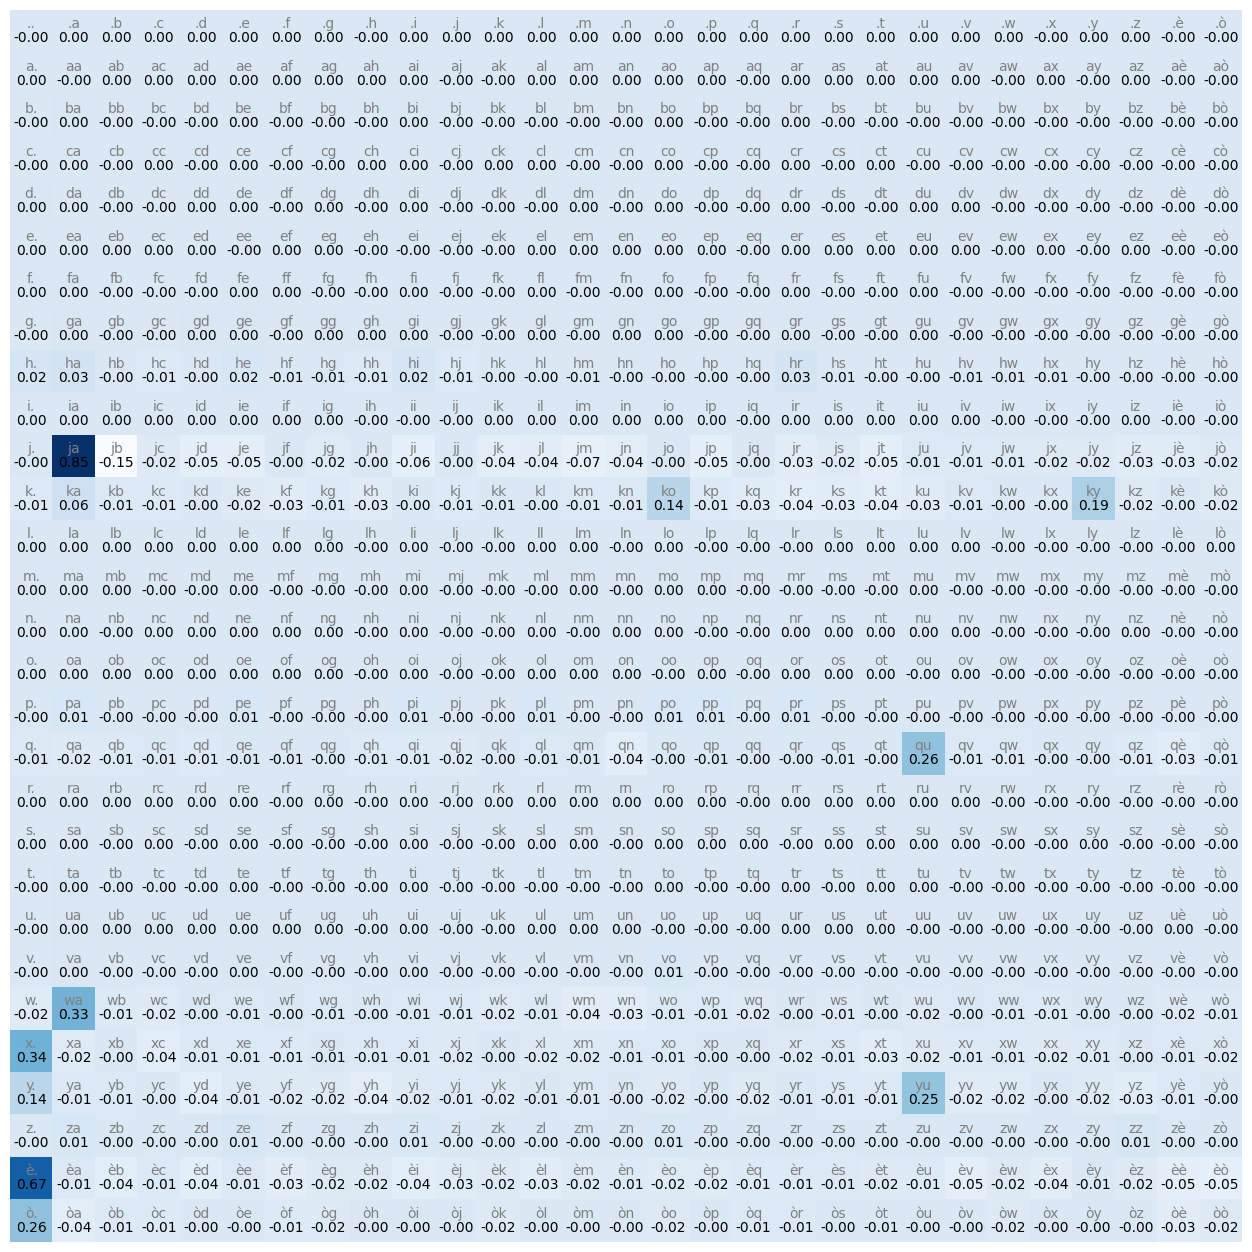

In [62]:
P_diff = P - P_w

plt.figure(figsize=(16, 16))
plt.imshow(P_diff.detach().numpy(), cmap='Blues')
for i in range(len(stoi)):
    for j in range(len(stoi)):
        plt.text(j, i, itos[i] + itos[j], ha='center', va='bottom', color='gray')
        plt.text(j, i, f'{P_diff[i, j]:.2f}', ha='center', va='top', color='black') 
plt.axis('off')

In [68]:
((P_diff**2)**1/2).mean()

tensor(0.0011, grad_fn=<MeanBackward0>)

In [12]:
gen_names = set()

for _ in range(1_000):
    letter = '.'
    name = ''
    while True:
        x_encoded = F.one_hot(torch.tensor([stoi[letter]]), num_classes=len(stoi)).float()
        logits = x_encoded @ W
        probs = F.softmax(logits, dim=1)
        letter = itos[torch.multinomial(probs, num_samples=1, replacement=True).item()]
        if letter == '.':
            break
        name += letter
    gen_names.add(name)

In [65]:
counter = 0

for name in sorted(gen_names):
    if name in names:
        print(name)
        counter += 1

print(f'{counter} out of {len(gen_names)} were real ({counter/len(gen_names)*100:.2f}%)')

alex
dario
ema
gina
gino
lia
mariano
miro
odo
pia
pina
11 out of 755 were real (1.46%)


## MLP Approach

---

Directly load trained model:

In [140]:
import pickle

with open('bn_model.pkl', 'rb') as f:
    embeddings, W1, b1, W2, b2, bn_gain, bn_bias, bn_mean_running, bn_var_running = pickle.load(f)

---

In [13]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []

for name in names[:2]:
    context = [0] * block_size
    for ch in name + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '----->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

... -----> c
..c -----> h
.ch -----> r
chr -----> i
hri -----> s
ris -----> t
ist -----> i
sti -----> a
tia -----> n
ian -----> .
... -----> w
..w -----> a
.wa -----> l
wal -----> t
alt -----> e
lte -----> r
ter -----> .


In [14]:
block_size = 3
X, Y = [], []

for name in names:
    context = [0] * block_size
    for ch in name + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [15]:
X.shape, Y.shape

(torch.Size([5156, 3]), torch.Size([5156]))

In [15]:
EMBEDDING_DIM = 2 # 2-dimensional embeddings (possibly underfitting, but we can visualize it)

In [16]:
embeddings = torch.randn((len(stoi), EMBEDDING_DIM))

In [ ]:
embeddings # initial random state of embeddings for each character in the vocabulary

tensor([[-0.7983, -0.2205],
        [ 0.0915, -0.1318],
        [ 0.4047, -0.3698],
        [ 0.9966,  1.2201],
        [ 0.8326, -1.4688],
        [ 2.5703, -1.4777],
        [-0.4378, -0.4694],
        [-0.4806,  1.2906],
        [-0.8861, -1.4300],
        [ 0.6442,  0.0633],
        [-1.4081, -0.5135],
        [-0.5357,  1.5791],
        [ 1.9022, -0.2800],
        [-1.0296,  0.5906],
        [-0.4436,  0.0844],
        [-0.1765,  0.5997],
        [ 0.3246,  0.9275],
        [ 0.1814,  0.6621],
        [-0.7191, -0.8245],
        [ 0.0262,  0.9199],
        [-1.4585, -0.6006],
        [ 0.2252,  0.8680],
        [-1.0594, -0.8861],
        [-1.4595,  0.0191],
        [-0.9463,  0.0955],
        [ 0.1613,  1.0480],
        [ 0.7508,  0.0818],
        [-2.6334, -0.4855],
        [-1.1825,  1.1485]])

In [17]:
input_embedding = embeddings[X]
input_embedding.shape

torch.Size([5156, 3, 2])

In [18]:
FIRST_LAYER_DIM = 200

In [19]:
# Let's build the first layer

W1 = torch.randn((block_size * embeddings[0].shape[0], FIRST_LAYER_DIM))
b1 = torch.randn(FIRST_LAYER_DIM)
emb = input_embedding.view(-1, block_size * embeddings[0].shape[0]).float()
hidden = torch.tanh(emb @ W1 + b1)

In [37]:
hidden

tensor([[-0.9865, -0.7742, -0.9994,  ..., -0.9927, -0.2393,  0.7506],
        [ 0.9245, -0.9998, -0.5667,  ..., -0.9980,  0.6218, -0.1276],
        [-0.9925, -0.2596, -1.0000,  ..., -0.9682, -0.8191,  0.9935],
        ...,
        [ 0.9746,  0.9856, -0.5044,  ...,  0.9971, -0.9292, -1.0000],
        [-0.9988,  0.9996,  0.9999,  ...,  0.9908, -0.9427, -0.9973],
        [-0.9999,  0.9701,  1.0000,  ...,  0.9982,  0.9998, -0.9972]])

In [20]:
# Second layer time

W2 = torch.randn((FIRST_LAYER_DIM, len(stoi)))
b2 = torch.randn(len(stoi))

In [21]:
logits = hidden @ W2 + b2
logits -= logits.max(1, keepdim=True).values # for numerical stability (e**logit can overflow)
probs = F.softmax(logits, dim=1)
# loss = -probs[torch.arange(len(probs)), Y].log().mean()
loss = F.cross_entropy(logits, Y)
loss

tensor(22.1651)

In [22]:
learning_rate = 0.1

In [23]:
g = torch.Generator().manual_seed(1337)
embeddings = torch.randn((len(stoi), EMBEDDING_DIM), generator=g)
W1 = torch.randn((block_size * EMBEDDING_DIM, FIRST_LAYER_DIM), generator=g)
b1 = torch.randn(FIRST_LAYER_DIM, generator=g)
W2 = torch.randn((FIRST_LAYER_DIM, len(stoi)), generator=g)
b2 = torch.randn(len(stoi), generator=g)

parameters = [embeddings, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [24]:
for k in range(10_000 + 1):
    # forward pass
    emb = embeddings[X].view(-1, block_size * embeddings[0].shape[0]).float()
    hidden = torch.tanh(emb @ W1 + b1)
    logits = hidden @ W2 + b2
    logits -= logits.max(1, keepdim=True).values
    loss = F.cross_entropy(logits, Y)
    if k % 1_000 == 0:
        print(f'{k:05} {loss.item():.4f}')
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data -= learning_rate * p.grad


00000 27.1643
01000 2.2846
02000 2.1834
03000 2.1341
04000 2.0957
05000 2.0641
06000 2.0413
07000 2.0205
08000 2.0005
09000 1.9818
10000 1.9645


### Learning Rate

In [25]:
g = torch.Generator().manual_seed(1337)
embeddings = torch.randn((len(stoi), EMBEDDING_DIM), generator=g)
W1 = torch.randn((block_size * EMBEDDING_DIM, FIRST_LAYER_DIM), generator=g)
b1 = torch.randn(FIRST_LAYER_DIM, generator=g)
W2 = torch.randn((FIRST_LAYER_DIM, len(stoi)), generator=g)
b2 = torch.randn(len(stoi), generator=g)

parameters = [embeddings, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [26]:
lre = torch.linspace(-3, 0, 1000 + 1)
learning_rates = 10**lre

00000 27.1643
00100 23.6790
00200 19.6667
00300 14.3793
00400 7.8448
00500 4.0982
00600 2.8781
00700 2.6480
00800 5.3530
00900 6.0602
01000 10.0042


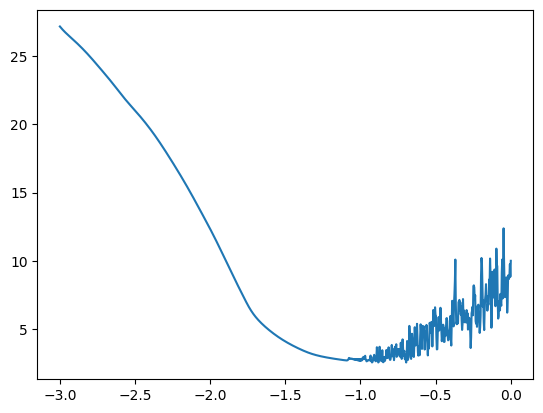

In [27]:
lossi = []
lrei = []

for k in range(1_000 + 1):
    # forward pass
    emb = embeddings[X].view(-1, block_size * embeddings[0].shape[0]).float()
    hidden = torch.tanh(emb @ W1 + b1)
    logits = hidden @ W2 + b2
    logits -= logits.max(1, keepdim=True).values
    loss = F.cross_entropy(logits, Y)
    if k % 100 == 0:
        print(f'{k:05} {loss.item():.4f}')
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data -= learning_rates[k] * p.grad
    # tracking
    lossi.append(loss.item())
    lrei.append(lre[k].item())

plt.plot(lrei, lossi)

In [28]:
LEARNING_RATE = 10**(-1.2)

In [29]:
g = torch.Generator().manual_seed(1337)
embeddings = torch.randn((len(stoi), EMBEDDING_DIM), generator=g)
W1 = torch.randn((block_size * EMBEDDING_DIM, FIRST_LAYER_DIM), generator=g)
b1 = torch.randn(FIRST_LAYER_DIM, generator=g)
W2 = torch.randn((FIRST_LAYER_DIM, len(stoi)), generator=g)
b2 = torch.randn(len(stoi), generator=g)

parameters = [embeddings, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

for k in range(10_000 + 1):
    # forward pass
    emb = embeddings[X].view(-1, block_size * embeddings[0].shape[0]).float()
    hidden = torch.tanh(emb @ W1 + b1)
    logits = hidden @ W2 + b2
    logits -= logits.max(1, keepdim=True).values
    loss = F.cross_entropy(logits, Y)
    if k % 1_000 == 0:
        print(f'{k:05} {loss.item():.4f}')
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data -= LEARNING_RATE * p.grad

00000 27.1643
01000 2.2940
02000 2.2069
03000 2.1621
04000 2.1341
05000 2.1126
06000 2.0950
07000 2.0801
08000 2.0667
09000 2.0541
10000 2.0417


### Training + Dev/Validation + Test sets

In [57]:
def build_dataset(names, block_size):
    X, Y = [], []
    for name in names:
        context = [0] * block_size
        for ch in name + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(names)
n1 = int(0.8 * len(names)) # 80% of the data for training
n2 = int(0.9 * len(names)) # 10% of the data for validation, 10% for testing

block_size = 3

Xtr, Ytr = build_dataset(names[:n1], block_size)
Xdev, Ydev = build_dataset(names[n1:n2], block_size)
Xte, Yte = build_dataset(names[n2:], block_size)

In [58]:
Xtr.shape, Ytr.shape, Xdev.shape, Ydev.shape, Xte.shape, Yte.shape

(torch.Size([4116, 3]),
 torch.Size([4116]),
 torch.Size([531, 3]),
 torch.Size([531]),
 torch.Size([509, 3]),
 torch.Size([509]))

In [59]:
g = torch.Generator().manual_seed(1337)
embeddings = torch.randn((len(stoi), EMBEDDING_DIM), generator=g)
W1 = torch.randn((block_size * EMBEDDING_DIM, FIRST_LAYER_DIM), generator=g)
b1 = torch.randn(FIRST_LAYER_DIM, generator=g)
W2 = torch.randn((FIRST_LAYER_DIM, len(stoi)), generator=g)
b2 = torch.randn(len(stoi), generator=g)

parameters = [embeddings, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [60]:
BATCH_SIZE = 300
LEARNING_RATE = 10**(-0.5)
DECAY = 0.999 # using decay on learninsg rate

learning_rate = LEARNING_RATE

for k in range(8_000 + 1):
    # mini-batch training
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))
    # forward pass
    emb = embeddings[Xtr[ix]].view(-1, block_size * embeddings[0].shape[0]).float()
    hidden = torch.tanh(emb @ W1 + b1)
    logits = hidden @ W2 + b2
    logits -= logits.max(1, keepdim=True).values
    loss = F.cross_entropy(logits, Ytr[ix])
    if k % 1_000 == 0:
        print(f'{k:05} {loss.item():.4f}')
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data -= learning_rate * p.grad
        learning_rate *= DECAY

00000 27.5709
01000 2.1516
02000 2.2076
03000 2.1217
04000 2.1220
05000 2.1827
06000 2.2336
07000 2.3683
08000 2.1439


In [61]:
emb = embeddings[Xdev].view(-1, block_size * embeddings[0].shape[0]).float()
hidden = torch.tanh(emb @ W1 + b1)
logits = hidden @ W2 + b2
logits -= logits.max(1, keepdim=True).values
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3388, grad_fn=<NllLossBackward0>)

In [62]:
emb = embeddings[Xte].view(-1, block_size * embeddings[0].shape[0]).float()
hidden = torch.tanh(emb @ W1 + b1)
logits = hidden @ W2 + b2
logits -= logits.max(1, keepdim=True).values
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.2919, grad_fn=<NllLossBackward0>)

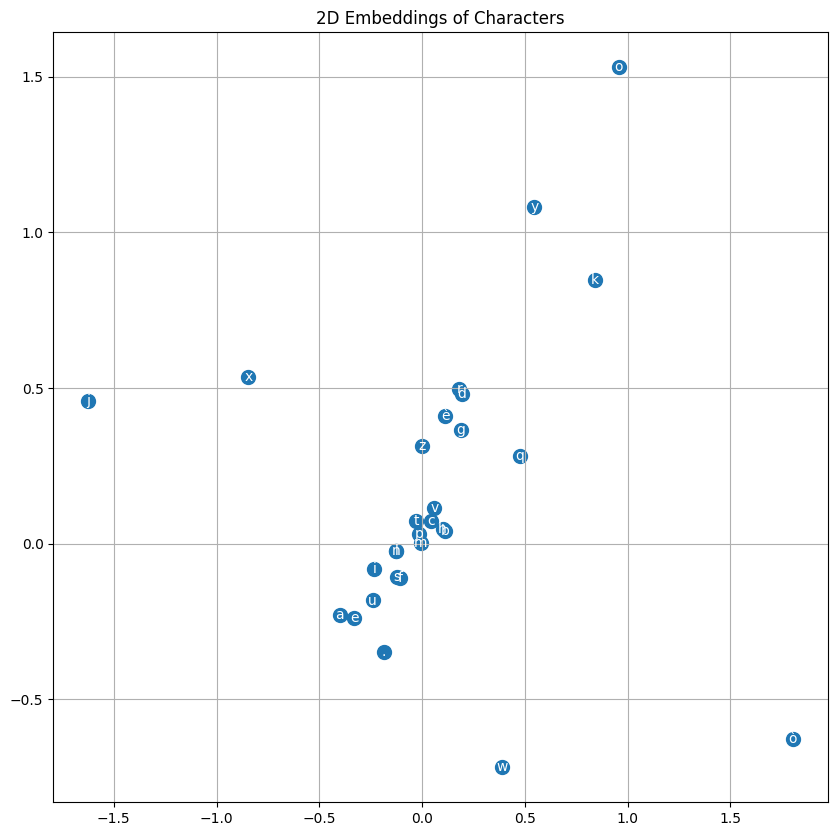

In [63]:
plt.figure(figsize=(10, 10))
plt.scatter(embeddings[:, 0].detach().numpy(), embeddings[:, 1].detach().numpy(), s=100)
for i in range(len(embeddings)):
    plt.text(embeddings[i, 0].item(), embeddings[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.title("2D Embeddings of Characters")
plt.grid('minor')
plt.show()

In [108]:
gen_names = []

for _ in range(1_000):
    letters = '...'
    name = ''
    while True:
        emb = torch.tensor([embeddings[stoi[s]].detach().numpy() for s in letters]).view(-1, block_size * embeddings[0].shape[0]).float()
        hidden = torch.tanh(emb @ W1 + b1)
        logits = hidden @ W2 + b2
        probs = F.softmax(logits, dim=1)
        letters = letters[1:] + itos[torch.multinomial(probs, num_samples=1, replacement=True).item()]
        if letters[-1] == '.':
            break
        name += letters[-1]
    gen_names.append(name)

In [109]:
counter = 0

for name in sorted(gen_names):
    if name in names:
        print(name)
        counter += 1

print(f'{counter} out of {len(gen_names)} were real ({counter/len(gen_names)*100:.2f}%)')

ada
aldo
carlo
edda
edo
elia
elio
enzo
gian
gino
ida
lia
lia
lia
mario
mario
nico
nino
pia
pia
rosa
21 out of 1000 were real (2.10%)


### Improving NN

- Too big loss at the start: just rescale weights and biases ($W_2$ and $b_2$)
- tanh for big numbers usually saturize: just rescale weights and biases ($W_1$ and $b_1$)
- BatchNorm (hidden normalized + bn_gain + bn_bias)

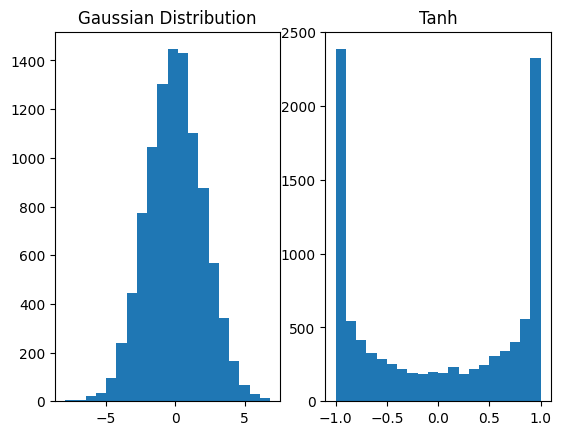

In [115]:
gauss = torch.randn(10_000) * 2
tanh = torch.tanh(gauss)

plt.subplot(1, 2, 1)
plt.title("Gaussian Distribution")
plt.hist(gauss, bins=20)
plt.subplot(1, 2, 2)
plt.title("Tanh")
plt.hist(tanh, bins=20)
plt.show()

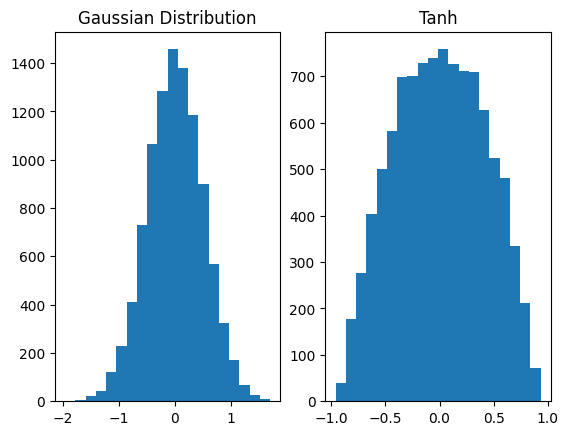

In [117]:
gauss = torch.randn(10_000) * 0.5
tanh = torch.tanh(gauss)

plt.subplot(1, 2, 1)
plt.title("Gaussian Distribution")
plt.hist(gauss, bins=20)
plt.subplot(1, 2, 2)
plt.title("Tanh")
plt.hist(tanh, bins=20)
plt.show()

In [ ]:
g = torch.Generator().manual_seed(1337)
embeddings = torch.randn((len(stoi), EMBEDDING_DIM), generator=g)
W1 = torch.randn((block_size * EMBEDDING_DIM, FIRST_LAYER_DIM), generator=g) * (5/3) * (EMBEDDING_DIM * block_size)**(-0.5) # Kaiming initialization (normalization + 5/3 for tanh)
# b1 = torch.randn(FIRST_LAYER_DIM, generator=g) * 0.01 # REMOVABLE (in normalization is already removed)
W2 = torch.randn((FIRST_LAYER_DIM, len(stoi)), generator=g) * 0.01
b2 = torch.randn(len(stoi), generator=g) * 0

bn_gain = torch.ones(FIRST_LAYER_DIM) # batch normalization gain
bn_bias = torch.zeros(FIRST_LAYER_DIM) # batch normalization bias

bn_mean_running = torch.zeros(FIRST_LAYER_DIM) # buffer mean for batch normalization
bn_var_running = torch.ones(FIRST_LAYER_DIM) # buffer variance for batch normalization

parameters = [embeddings, W1, W2, b2, bn_gain, bn_bias]

for p in parameters:
    p.requires_grad = True

In [ ]:
BATCH_SIZE = 300
LEARNING_RATE = 10**(-0.5)
DECAY = 0.999 # using decay on learninsg rate

EPS = 1e-5 # for numerical stability in normalization

learning_rate = LEARNING_RATE

for k in range(8_000 + 1):
    # mini-batch training
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))
    # forward pass
    emb = embeddings[Xtr[ix]].view(-1, block_size * embeddings[0].shape[0]).float()
    hidden_preact = emb @ W1 # + b1
    bn_mean = hidden_preact.mean(0, keepdim=True)
    bn_var = hidden_preact.var(0, keepdim=True, unbiased=False)
    hidden_preact = (hidden_preact - bn_mean) / (bn_var.sqrt() + EPS) # normalization
    hidden_preact = bn_gain * hidden_preact + bn_bias # batch normalization

    with torch.no_grad():
        bn_mean_running = 0.95 * bn_mean_running + 0.05 * bn_mean.view(-1) # buffer update (mean)
        bn_var_running = 0.95 * bn_var_running + 0.05 * bn_var.view(-1) # buffer update (variance)

    hidden = torch.tanh(hidden_preact)
    logits = hidden @ W2 + b2
    logits -= logits.max(1, keepdim=True).values
    loss = F.cross_entropy(logits, Ytr[ix])
    if k % 1_000 == 0:
        print(f'{k:05} {loss.item():.4f}')
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data -= learning_rate * p.grad
        learning_rate *= DECAY

00000 3.3715
01000 2.2438
02000 2.3384
03000 2.3469
04000 2.3031
05000 2.2569
06000 2.2069
07000 2.3401
08000 2.3331


In [138]:
import pickle

with open('bn_model.pkl', 'wb') as f:
    pickle.dump({
        'embeddings': embeddings.detach().numpy(),
        'W1': W1.detach().numpy(),
        'b1': b1.detach().numpy(),
        'W2': W2.detach().numpy(),
        'b2': b2.detach().numpy(),
        'bn_gain': bn_gain.detach().numpy(),
        'bn_bias': bn_bias.detach().numpy(),
        'bn_mean_running': bn_mean_running.detach().numpy(),
        'bn_var_running': bn_var_running.detach().numpy()
    }, f)

## PyTorchifying the code

In [141]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
        self.weight.requires_grad = True
        self.bias.requires_grad = True

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight, self.bias] if self.bias is not None else [self.weight]

In [ ]:
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / (xvar.sqrt() + self.eps) # normalized
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean # buffer update (mean)
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar # buffer update (variance)

        return self.out

In [143]:
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [190]:
EMBEDDING_DIM = 3
HIDDEN_NEURONS = 100

C = torch.randn((len(stoi), EMBEDDING_DIM))
layers = [Linear(EMBEDDING_DIM * block_size, HIDDEN_NEURONS), Tanh(),
          Linear(HIDDEN_NEURONS, HIDDEN_NEURONS), Tanh(),
          Linear(HIDDEN_NEURONS, HIDDEN_NEURONS), Tanh(),
          Linear(HIDDEN_NEURONS, HIDDEN_NEURONS), Tanh(),
          Linear(HIDDEN_NEURONS, HIDDEN_NEURONS), Tanh(),
          Linear(HIDDEN_NEURONS, len(stoi))]

with torch.no_grad():
    layers[-1].weight *= 0.1 # less confident predictor after softmax
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3 # Kaiming for tanh

parameters = [p for layer in layers for p in layer.parameters() if p is not None]
for p in parameters:
    p.requires_grad = True

In [191]:
STEPS = 6_000 + 1
BATCH_SIZE = 100
lossi = []
ud = []
learning_rate = 10**(-0.5)
DECAY = 0.999

for i in range(STEPS):
    # mini-batch
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data -= learning_rate * p.grad
    learning_rate *= DECAY
    # track
    if i % 1_000 == 0:
        print(f'{i:05} {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((learning_rate * p.grad).std() / p.data.std()).log10().item() for p in parameters])

00000 3.3646
01000 1.5917
02000 1.1995
03000 1.3258
04000 1.3887
05000 1.2463
06000 1.2783


Layer 1 (Tanh): mean 0.0116, std 0.7313, satured 17.42%
Layer 3 (Tanh): mean 0.0051, std 0.7809, satured 25.32%
Layer 5 (Tanh): mean 0.0275, std 0.7705, satured 23.00%
Layer 7 (Tanh): mean 0.0137, std 0.7724, satured 21.16%
Layer 9 (Tanh): mean -0.0013, std 0.7537, satured 16.44%


Text(0.5, 1.0, 'Activation distribution')

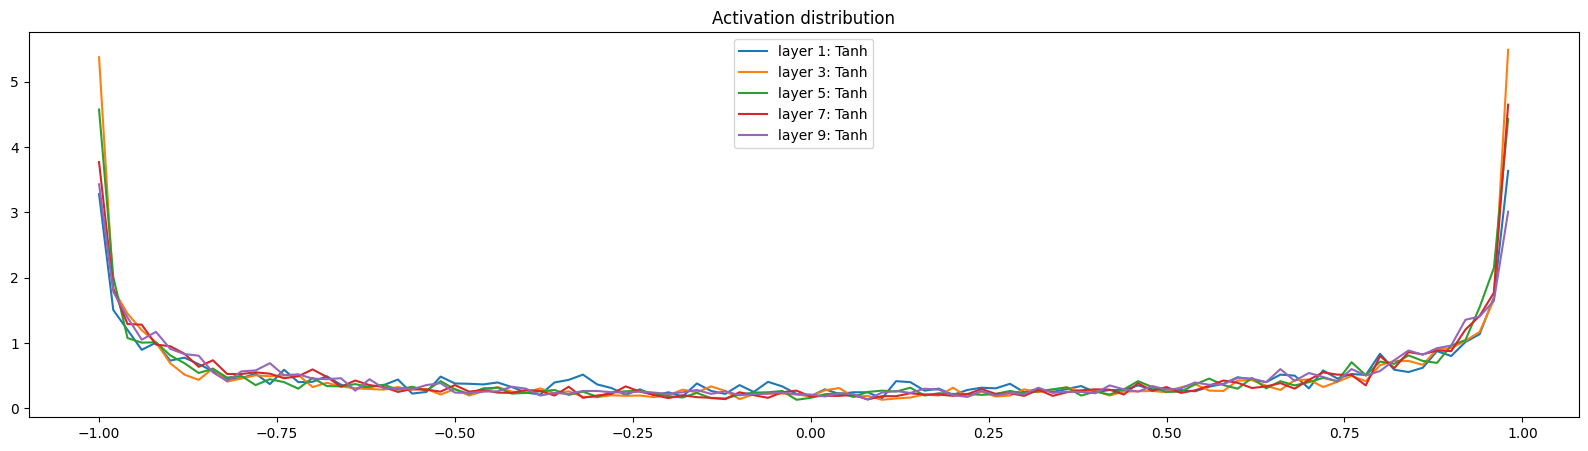

In [192]:
plt.figure(figsize=(20, 5))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('Layer %d (%4s): mean %.4f, std %.4f, satured %.2f%%' % (i, layer.__class__.__name__[:4], t.mean().item(), t.std().item(), (t.abs() > 0.97).float().mean().item() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i}: {layer.__class__.__name__}')
plt.legend(legends)
plt.title('Activation distribution')

Without $\frac{5}{3}$ multiplier for every layer output the distribution would have squeezed.

Layer 0 (Line): mean 0.0361, std 1.5621
Layer 2 (Line): mean 0.0079, std 1.8289
Layer 4 (Line): mean 0.0488, std 1.7413
Layer 6 (Line): mean 0.0572, std 1.7032
Layer 8 (Line): mean -0.0189, std 1.5303


Text(0.5, 1.0, 'Activation distribution')

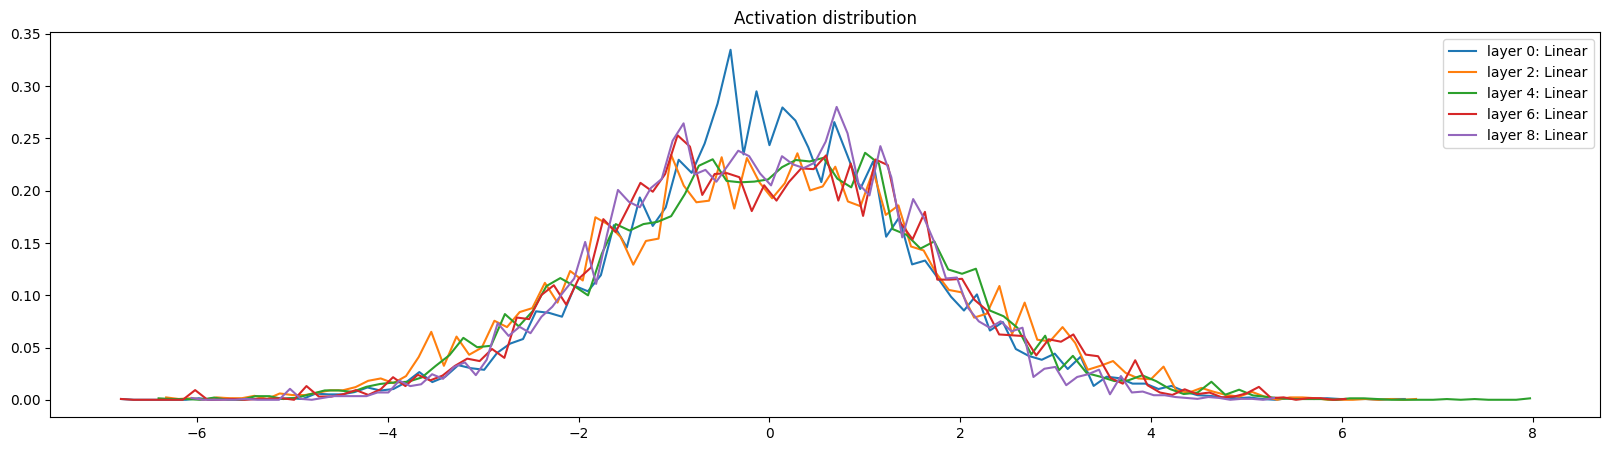

In [194]:
plt.figure(figsize=(20, 5))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Linear):
        t = layer.out
        print('Layer %d (%4s): mean %.4f, std %.4f' % (i, layer.__class__.__name__[:4], t.mean().item(), t.std().item()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i}: {layer.__class__.__name__}')
plt.legend(legends)
plt.title('Activation distribution')

Layer 1 (Tanh): mean -0.0000, std 0.0028
Layer 3 (Tanh): mean -0.0000, std 0.0026
Layer 5 (Tanh): mean -0.0000, std 0.0026
Layer 7 (Tanh): mean 0.0000, std 0.0022
Layer 9 (Tanh): mean 0.0000, std 0.0017


Text(0.5, 1.0, 'gradient distribution')

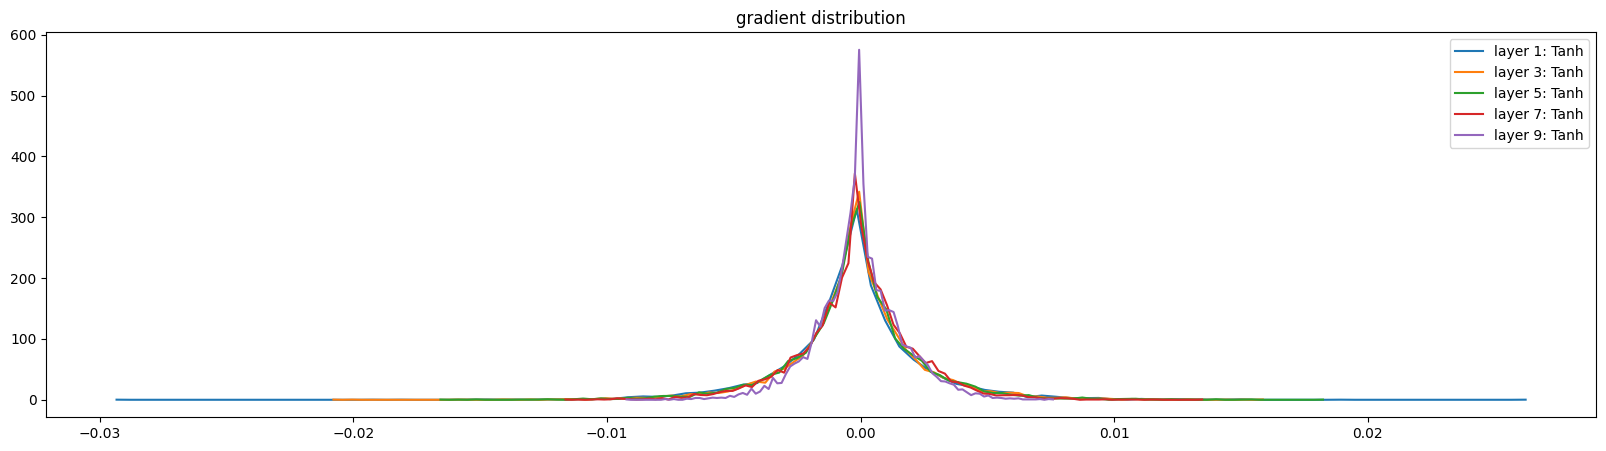

In [195]:
plt.figure(figsize=(20, 5))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('Layer %d (%4s): mean %.4f, std %.4f' % (i, layer.__class__.__name__[:4], t.mean().item(), t.std().item()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i}: {layer.__class__.__name__}')
plt.legend(legends)
plt.title('gradient distribution')

Layer 0 (Line): mean -0.0000, std 0.0016
Layer 2 (Line): mean -0.0000, std 0.0014
Layer 4 (Line): mean -0.0000, std 0.0013
Layer 6 (Line): mean -0.0000, std 0.0012
Layer 8 (Line): mean 0.0000, std 0.0009


Text(0.5, 1.0, 'gradient distribution')

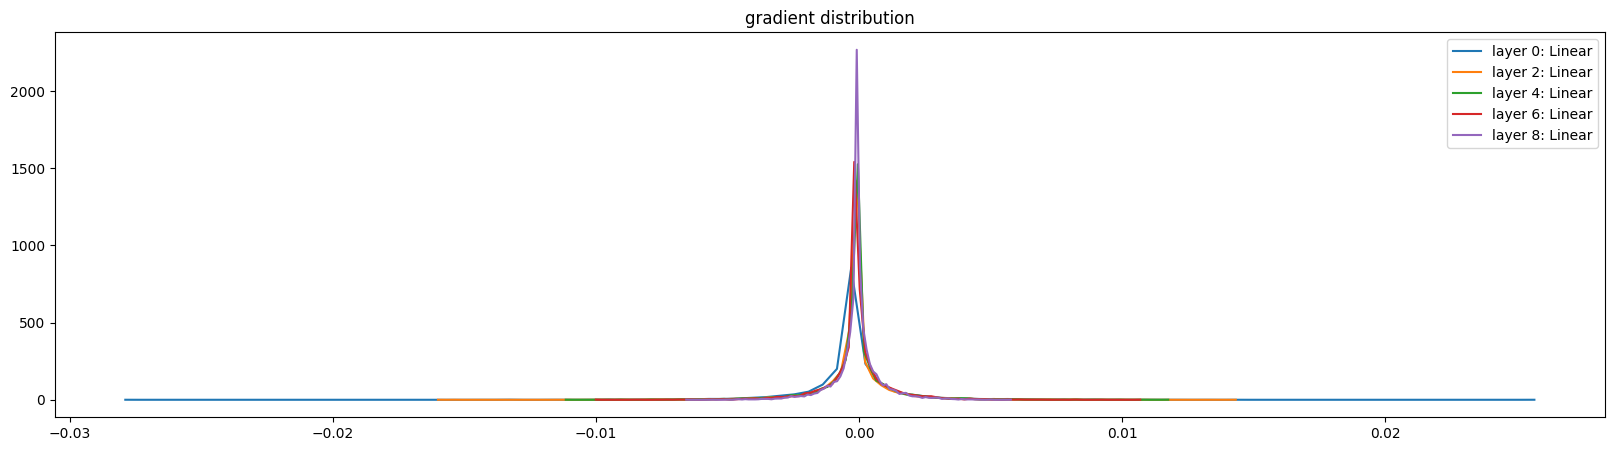

In [196]:
plt.figure(figsize=(20, 5))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Linear):
        t = layer.out.grad
        print('Layer %d (%4s): mean %.4f, std %.4f' % (i, layer.__class__.__name__[:4], t.mean().item(), t.std().item()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i}: {layer.__class__.__name__}')
plt.legend(legends)
plt.title('gradient distribution')

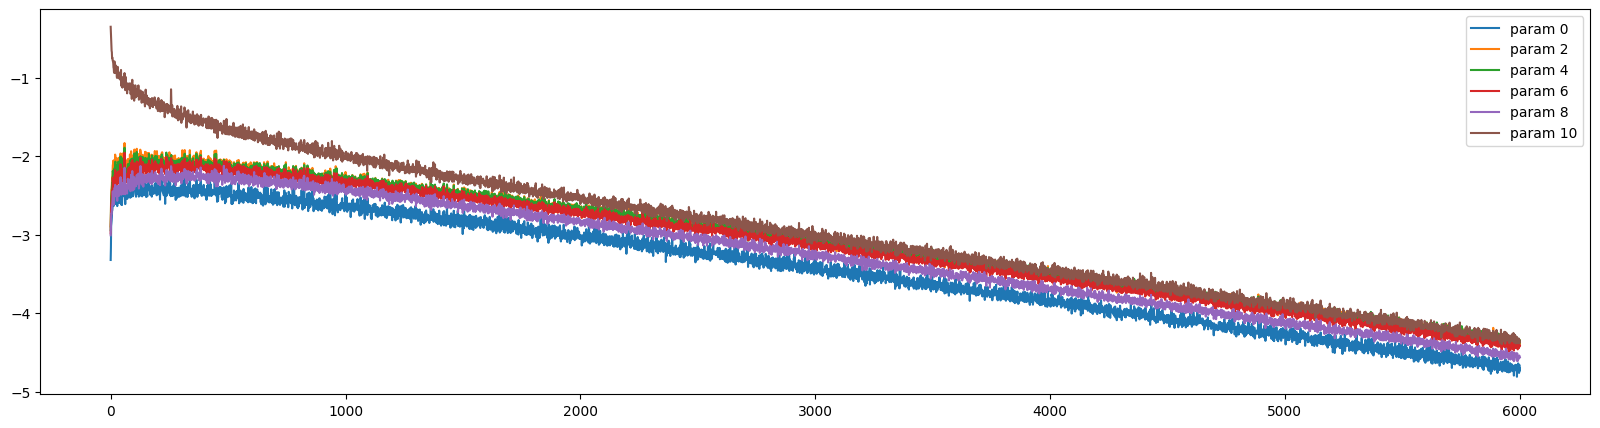

In [ ]:
plt.figure(figsize=(20, 5))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f'param {i}')
plt.legend(legends)

Pendency is due to DECAY parameter.

$-3$ is the optimal ratio.